In [1]:
import matplotlib.pyplot as plt
import copy
import os, json, numpy as np, torch
from typing import Tuple, Dict
import numpy as np
import torch

# Neuromancer imports: modeling, loss, logging, system dynamics
from neuromancer.loggers import BasicLogger
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library
from SparseDPC.data.getdata import get_data
from SparseDPC.trainer.trainer import SparseTrainer
from SparseDPC.utils.integrator import OneElementEulerIntegrator, FullStateEulerIntegrator
from SparseDPC.trainer.problem import SparsePolicyBuilder

# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


### Create ODE for DoubleIntegrator

In [2]:
# Ground truth system model
from utils import DoubleIntegrator2D


gt_model = DoubleIntegrator2D()
gt_model.params
# Sampling rate
ts = gt_model.params[1]["ts"]

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = -2.
umax = +2.
xmin = -5.
xmax = +5.


#### Get training data for system ID

In [3]:
nsim = 2000   # number of simulation steps in the dataset
nsteps = 4  # number of prediction horizon steps in the loss function
bs = 200     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

#### SINDy for Dynamics

In [4]:
dyn_cfg = {
    # ---------- loss weights ----------
    "onestep_coef"   : 1.0,      # 1-step prediction error
    "ref_coef"       : 2.0,      # full-horizon (n-step) error
    "l1_coef"        : 1e-6,     # L¹ sparsity on SINDy coefficients

    # ---------- optimiser / schedule ----------
    "lr"             : 1e-3,     # AdamW learning-rate
    "epochs"         : 9999,   # gradient steps per coordinate model

    # ---------- pruning & early-stop ----------
    "threshold"      : 5e-2,     # initial coefficient cutoff
    "prune_every"    : 2000,    # epochs between pruning passes
    "threshold_mult" : 1.09,     # threshold ← threshold × multiplier
    "prune_noise"    : 0.05,     # std-dev of regrowth noise (0 ⇒ none)

    # ---------- training conveniences ----------
    "warmup"         : 300,      # epochs before enabling pruning
    "patience"       : 50,       # early-stop patience on dev_loss
}


In [5]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=2, add_sqrt=False, add_u_prod=False) for i in range(nx)]
# Print model structures
for i,fx in enumerate(fx_models):
    print(f"Fx for x{i}")
    print(fx)


Fx for x0
dx0/dt = -0.000*x0 + 0.027*x1 + -0.041*x2 + -0.037*x3 + -0.019*x0^2 + 0.013*x0*x1 + -0.001*x0*x2 + 0.040*x0*x3 + -0.004*x1^2 + 0.013*x1*x2 + -0.015*x1*x3 + -0.010*x2^2 + -0.048*x2*x3 + -0.033*x3^2 + -0.021*u_0 + 0.002*u_1 + 0.020*x0*u_0 + 0.030*x1*u_0 + -0.034*x2*u_0 + -0.022*x3*u_0 + 0.018*x0*u_1 + 0.042*x1*u_1 + -0.010*x2*u_1 + 0.037*x3*u_1

Fx for x1
dx1/dt = -0.000*x1 + 0.027*x0 + -0.041*x2 + -0.037*x3 + -0.019*x0^2 + 0.013*x0*x1 + -0.001*x0*x2 + 0.040*x0*x3 + -0.004*x1^2 + 0.013*x1*x2 + -0.015*x1*x3 + -0.010*x2^2 + -0.048*x2*x3 + -0.033*x3^2 + -0.021*u_0 + 0.002*u_1 + 0.020*x0*u_0 + 0.030*x1*u_0 + -0.034*x2*u_0 + -0.022*x3*u_0 + 0.018*x0*u_1 + 0.042*x1*u_1 + -0.010*x2*u_1 + 0.037*x3*u_1

Fx for x2
dx2/dt = -0.000*x2 + 0.027*x0 + -0.041*x1 + -0.037*x3 + -0.019*x0^2 + 0.013*x0*x1 + -0.001*x0*x2 + 0.040*x0*x3 + -0.004*x1^2 + 0.013*x1*x2 + -0.015*x1*x3 + -0.010*x2^2 + -0.048*x2*x3 + -0.033*x3^2 + -0.021*u_0 + 0.002*u_1 + 0.020*x0*u_0 + 0.030*x1*u_0 + -0.034*x2*u_0 + -0.022*x

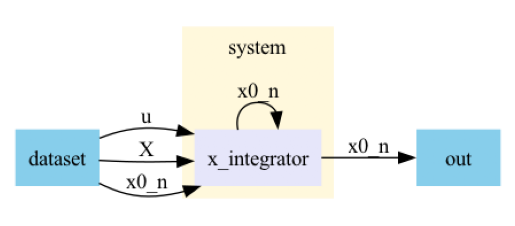

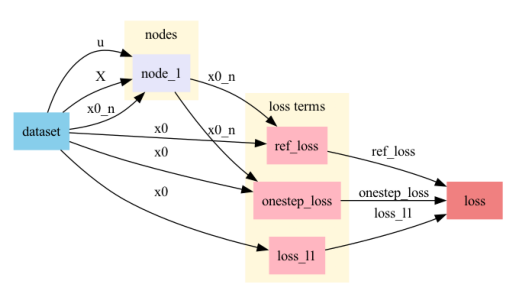

None
epoch: 0	train_loss: 510.09595	dev_loss: 810.13788	eltime:  1.79051
Training interrupted.


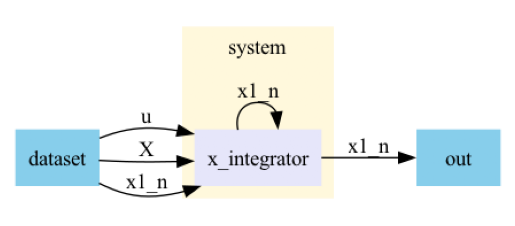

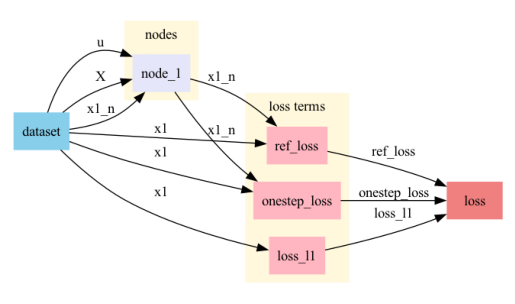

None



KeyboardInterrupt



In [6]:
for i in range(nx):
    # One-element integrator for current state
    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])
    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Define losses
    onestep_loss_x = dyn_cfg["onestep_coef"] * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = dyn_cfg["ref_coef"] * ((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # L1 sparsity regularization on model weights
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = dyn_cfg["l1_coef"] * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    # Assemble problem
    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = dyn_cfg["lr"]
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(
        args=None,
        savedir='test',
        verbosity=200,
        stdout=['dev_loss', 'train_loss']
    )

    trainer_x = SparseTrainer(
        problem=problem_x,
        fx_models=[fx_models[i]],
        lr=lr,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=dyn_cfg["epochs"],
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=dyn_cfg["threshold"],
        prune_every=dyn_cfg["prune_every"],
        warmup=300,
        patience=50,
        threshold_mult=dyn_cfg["threshold_mult"],
        prune_noise=dyn_cfg["prune_noise"],
    )

    for _ in range(1):
        # Regenerate training data for updated horizon
        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x

        # Train
        best_model = trainer_x.train()
        trainer_x.model.load_state_dict(best_model)

        # Double prediction steps
        nsteps *= 2
        dynamics_model_x.nsteps = nsteps

In [323]:
# Final SINDy models for each state
for fx in fx_models:
    print(fx)

dx0/dt = 1.000*x1

dx1/dt = -0.198*x1 + 0.990*u_0

dx2/dt = 1.000*x3

dx3/dt = -0.198*x3 + 0.990*u_1



#### Rollout on test data

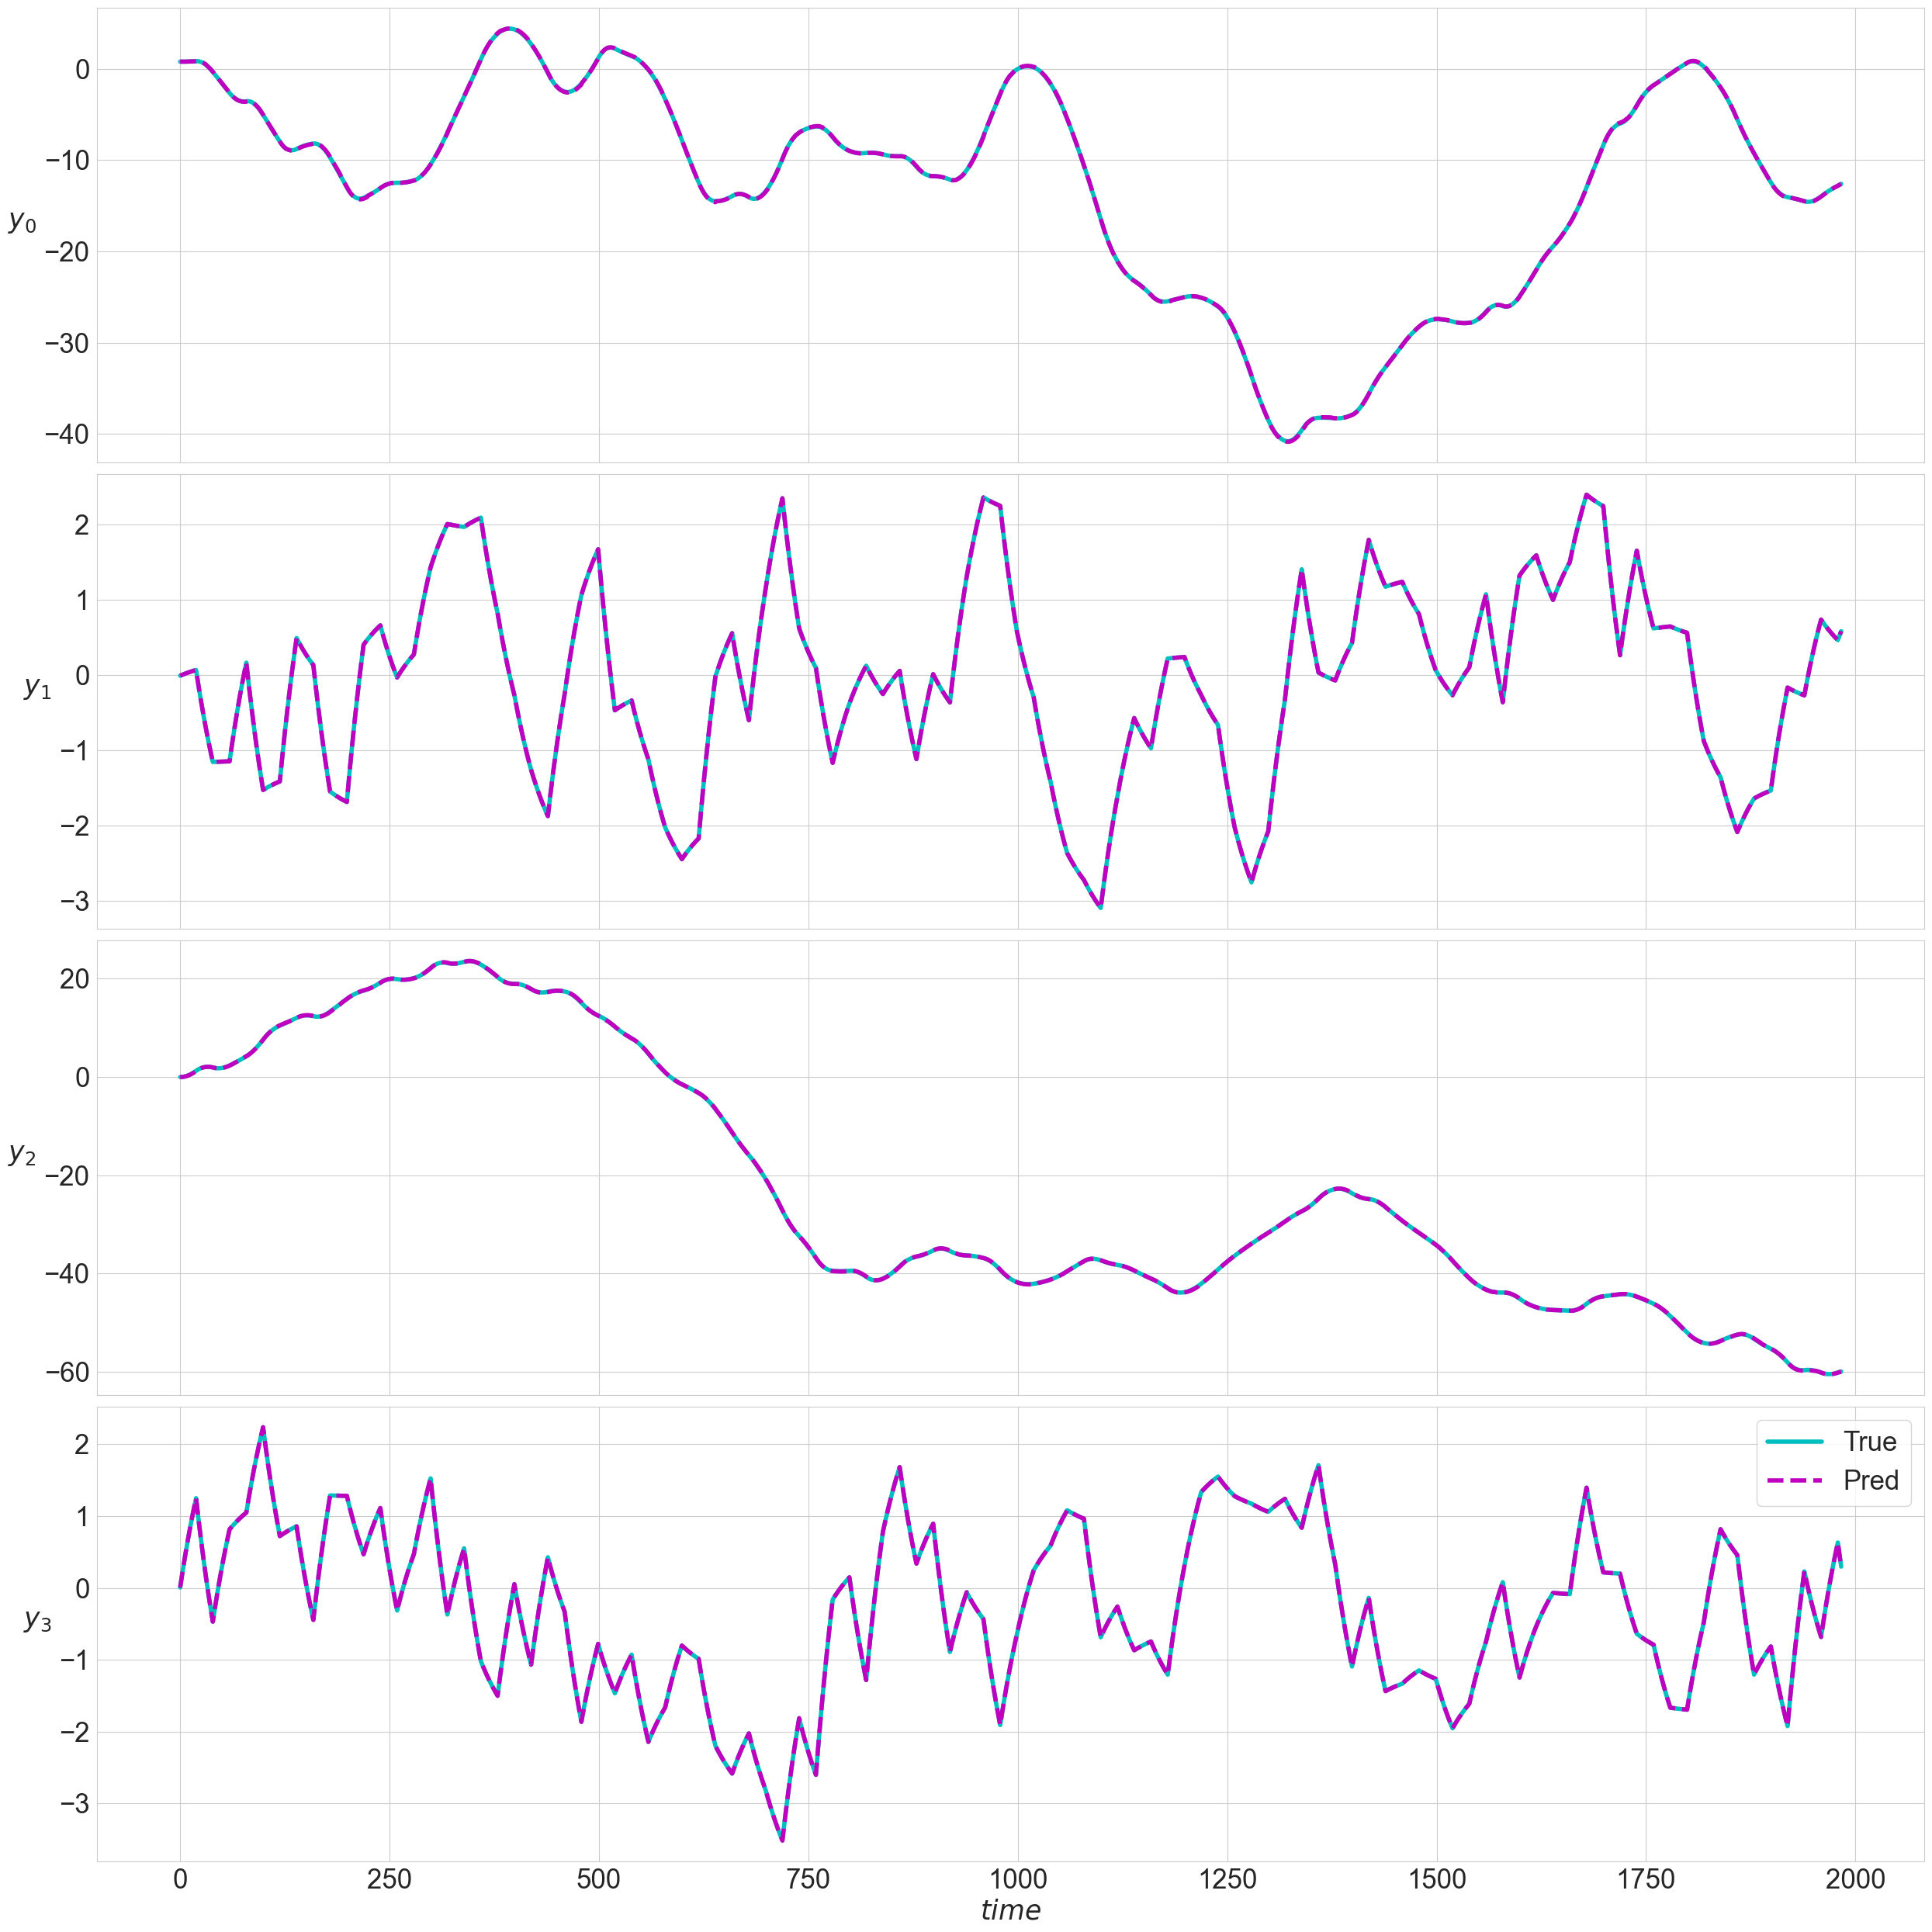

In [143]:
# Full-state integration using all fx_models
integrator_x = FullStateEulerIntegrator(fx_models, ts)
x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")

# Create system for evaluation
sindy_system = System([x_integrator_node], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()


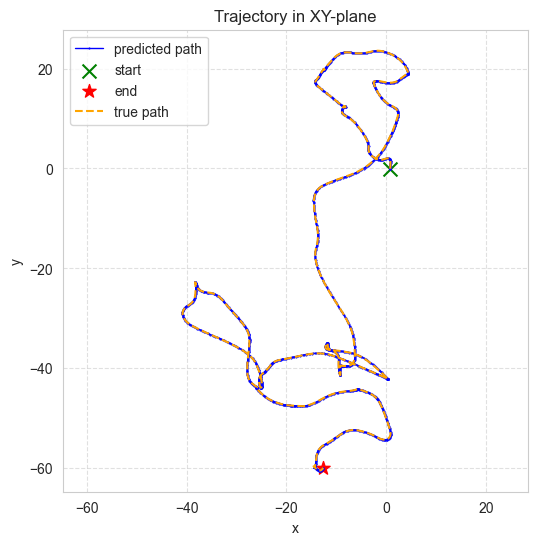

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
def plot_traj(pred_traj, true_traj=None, title="Trajectory in XY-plane"):
    """
    pred_traj: numpy array of shape (4, T)
               rows: [x, xdot, y, ydot]
    true_traj: numpy array of shape (4, T) (optional)
    """
    x_pred = pred_traj[0, :]
    y_pred = pred_traj[2, :]

    plt.figure(figsize=(6,6))
    # predicted
    plt.plot(x_pred, y_pred, marker="o", markersize=0.5, linewidth=1.0,
             label="predicted path", color="blue")
    plt.scatter(x_pred[0], y_pred[0], c="green", marker="x", s=100, label="start")
    plt.scatter(x_pred[-1], y_pred[-1], c="red", marker="*", s=100, label="end")

    # true path if given
    if true_traj is not None:
        x_true = true_traj[0, :]
        y_true = true_traj[2, :]
        plt.plot(x_true, y_true, linewidth=1.5, linestyle="--", color="orange", label="true path")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

# Example:
plot_traj(pred_traj, true_traj)


#### Save the system ID models

In [303]:
from SparseDPC.utils.utils       import map_to_new_fx, save_model_with_timestamp
from pathlib import Path

# ---------------- user-supplied objects & constants ------------------------ #
base_dir       = "results/tests/dynamics"
# --------------------------------------------------------------------------- #

run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(dyn_cfg, indent=4)))

models_dir = run_dir / "saved_models"; models_dir.mkdir()

for i in range(nx):
    # ---- prepare *mapped* model to full library & save .pt ----------
    full_lib   = fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=2, add_sqrt=False, add_u_prod=False)

    mapped_pol = map_to_new_fx(fx_models[i], full_lib)
    save_model_with_timestamp(mapped_pol,
                              f"trained_dynamics_x{i}",
                              models_dir)

    # ---- JSON log of the *trained (pruned) dynamics* ------------------
    orig_fx = fx_models[i]
    coef   = orig_fx.coef.detach().cpu().numpy().flatten().tolist()
    fnames = orig_fx.library.function_names
    expr   = str(orig_fx)

    log_entry = {
        "function_names": fnames,
        "coef":           coef,
        "expr":           expr
    }
    with open(run_dir / f"x{i}_log.json", "w") as f:
        json.dump(log_entry, f, indent=2)

print(f"✓  results saved under  {run_dir.as_posix()}")


✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x0_20250903_121728.pth
✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x1_20250903_121728.pth
✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x2_20250903_121728.pth
✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x3_20250903_121728.pth
✓  results saved under  results/tests/dynamics/run_1


## Training the controller

### Policy dataset with obstacle exclusion

- Builds train/dev `DataLoader`s for policy learning.
- Samples initial states (`xn`) and constant references (`r`) from rectangles.
- Rejects points inside ellipse:
  \( b(x-c)^2 + (y-d)^2 \ge (p/2)^2 \).

**Main steps**
- RNG split via `seed` (train/dev).
- `sample_xy_in_rect_outside`: uniform rect sampling with ellipse rejection.
- `_build_split`:
  - `xn`: positions + zero velocities.
  - `r`: constant ref over horizon.
  - Add obstacle params.

**Outputs**
- `train_loader`, `dev_loader` with dicts:
  - `"xn"` (B,1,nx), `"r"` (B,nsteps+1,2), `"obs_*"`.


In [7]:
from neuromancer.dataset import DictDataset

# assumes DictDataset is already defined/imported

from typing import Tuple, Optional
import torch
from torch.utils.data import DataLoader

# assumes DictDataset is already defined/imported

def get_policy_data(
    nsteps: int,
    n_samples: int,
    nx: int,
    device: torch.device,
    *,
    pos_idx: Tuple[int, int] = (0, 2),   # indices of x,y in the state vector
    batch_size: int = 200,
    seed: Optional[int] = None,
    # Rectangles are ((x_min, y_min), (x_max, y_max))
    init_rect: Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
    ref_rect:  Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
    # Ellipse parameters for obstacle exclusion
    ellipse_configs: dict = {"p": 10.0, "b": 8.0, "c": 1.0, "d": 2.0},
) -> Tuple[DataLoader, DataLoader]:
    """
    Generate training/dev datasets:
      - Initial positions sampled uniformly in init_rect; velocities = 0.
      - References sampled uniformly in ref_rect, held constant over horizon.
      - Any samples that fall INSIDE the obstacle ellipse are rejected.
    No margins or extra clearance.
    """

    # RNG
    if seed is None:
        gen_train = gen_dev = None
    else:
        gen_train = torch.Generator(device=device).manual_seed(seed)
        gen_dev   = torch.Generator(device=device).manual_seed(seed + 1)

    # Ellipse params
    p = float(ellipse_configs["p"])
    b = float(ellipse_configs["b"])
    c = float(ellipse_configs["c"])
    d = float(ellipse_configs["d"])
    assert b > 0.0 and p >= 0.0

    def outside_ellipse(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # keep points whose quadratic form is >= (p/2)^2 (i.e., OUTSIDE the ellipse)
        return (b * (x - c)**2 + (y - d)**2) >= (p * 0.5)**2

    def sample_xy_in_rect_outside(
        n: int,
        rect: Tuple[Tuple[float, float], Tuple[float, float]],
        gen: Optional[torch.Generator],
        max_iters: int = 100,
        chunk: int = 4096,
    ) -> torch.Tensor:
        (x0, y0), (x1, y1) = rect
        # allow unordered corners
        if x1 < x0: x0, x1 = x1, x0
        if y1 < y0: y0, y1 = y1, y0
        assert x1 > x0 and y1 > y0, "Rectangle must have positive width/height."

        out = torch.empty(0, 2, device=device)
        need = n
        it = 0
        while need > 0 and it < max_iters:
            m = max(need, chunk)
            xs = x0 + (x1 - x0) * torch.rand((m,), device=device, generator=gen)
            ys = y0 + (y1 - y0) * torch.rand((m,), device=device, generator=gen)
            keep = outside_ellipse(xs, ys)
            if keep.any():
                block = torch.stack([xs[keep], ys[keep]], dim=1)
                out = torch.cat([out, block], dim=0)
                need = n - out.shape[0]
            it += 1

        if out.shape[0] < n:
            raise RuntimeError(
                f"Could not sample {n} points outside the ellipse within the given rectangle "
                f"after {it} iterations. Consider changing the rectangle or the ellipse."
            )
        return out[:n]

    def _build_split(name: str, gen: Optional[torch.Generator]) -> "DictDataset":
        # Initial state: positions in init_rect but OUTSIDE ellipse; velocities = 0
        xy0 = sample_xy_in_rect_outside(n_samples, init_rect, gen)
        xn = torch.zeros((n_samples, 1, nx), device=device)
        xn[:, 0, pos_idx[0]] = xy0[:, 0]
        xn[:, 0, pos_idx[1]] = xy0[:, 1]

        # Reference positions (constant over horizon) in ref_rect, OUTSIDE ellipse
        xy_ref = sample_xy_in_rect_outside(n_samples, ref_rect, gen)
        r = torch.zeros((n_samples, nsteps + 1, 2), device=device)
        r[:, :, 0] = xy_ref[:, 0].unsqueeze(1).repeat(1, nsteps + 1)
        r[:, :, 1] = xy_ref[:, 1].unsqueeze(1).repeat(1, nsteps + 1)

        dct = {
            "xn": xn,                        # (n_samples, 1, nx)
            "r": r,                          # (n_samples, nsteps+1, 2)
            "obs_p": torch.full((n_samples, 1, 1), p, device=device),
            "obs_b": torch.full((n_samples, 1, 1), b, device=device),
            "obs_c": torch.full((n_samples, 1, 1), c, device=device),
            "obs_d": torch.full((n_samples, 1, 1), d, device=device),
        }
        return DictDataset(dct, name=name)

    train_data = _build_split("train", gen_train)
    dev_data   = _build_split("dev",   gen_dev)

    train_loader = DataLoader(train_data, batch_size=batch_size,
                              shuffle=False, collate_fn=train_data.collate_fn)
    dev_loader   = DataLoader(dev_data, batch_size=batch_size,
                              shuffle=False, collate_fn=dev_data.collate_fn)
    return train_loader, dev_loader




# Equation of the constrained area

Interior (points we **don’t** want to enter):

$$
\boxed{\;b\,(x-c)^2 + (y-d)^2 \;\le\; \left(\tfrac{p}{2}\right)^2\;}
$$

* Center: $(c,d)$
* Shape : $(b,p)$



In [24]:
ellipse_configs = {"p": 0.6,
                   "b": 1,
                   "c": 0.0,
                   "d": 0.0}

def make_square(center, length):
    """
    Build a rectangle ((x1,y1),(x2,y2)) from center and side length.
    center: (cx, cy)
    length: full side length
    """
    cx, cy = center
    half = length / 2.0
    return ((cx - half, cy - half), (cx + half, cy + half))

side = 0.5   # for example, 0.5 x 0.5 squares

# initial region center
init_center = (0.6, -0.6)
init_rect = make_square(init_center, side)

# reference region center)
ref_center = (-0.6, 0.6)
ref_rect = make_square(ref_center, side)

nsteps = 40
xmin = -1.
xmax = 1.
umin = -1.
umax = 1.

train_loader, dev_loader = get_policy_data(
    nsteps=nsteps, n_samples=3000, nx=4, device=device,
    ellipse_configs=ellipse_configs,
    init_rect=init_rect, ref_rect=ref_rect,
)


##### Helper functions

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle

def _rect_corners_to_llwh(rect):
    """
    rect: ((x1, y1), (x2, y2)) with any corner order.
    returns: (x_ll, y_ll, width, height), and (xmin, xmax, ymin, ymax)
    """
    (x1, y1), (x2, y2) = rect
    xmin, xmax = min(x1, x2), max(x1, x2)
    ymin, ymax = min(y1, y2), max(y1, y2)
    return (xmin, ymin, xmax - xmin, ymax - ymin), (xmin, xmax, ymin, ymax)

def plot_training_sample_with_ellipse(
    loader,
    sample_idx: int = 0,
    pos_idx=(0, 2),           # (x_index, y_index). For nx=2 use (0,1)
    *,
    p: float | None = None,
    b: float | None = None,
    c: float | None = None,
    d: float | None = None,
    title: str = "Training sample: init vs. reference with ellipse obstacle",
    init_rect=None,           # ((x1,y1),(x2,y2)) start sampling region
    ref_rect=None,            # ((x1,y1),(x2,y2)) reference sampling region
    xmin=-1., xmax=1.         # plot limits (square)
):
    # get one batch
    batch = next(iter(loader))
    xn = batch["xn"].detach().cpu().numpy()         # (B, 1, nx)
    r  = batch["r"].detach().cpu().numpy()          # (B, N+1, nx)

    # read ellipse params if missing
    def get_param(name, fallback):
        if fallback is None and name in batch:
            return float(batch[name][sample_idx].reshape(-1)[0])
        return fallback

    p  = get_param("obs_p", p)
    b_ = get_param("obs_b", b)
    c_ = get_param("obs_c", c)
    d_ = get_param("obs_d", d)

    if None in (p, b_, c_, d_):
        raise ValueError("Ellipse params p,b,c,d must be provided or present in the batch as obs_*.")

    # extract initial (single) and reference (assumed constant across horizon for xy)
    x_i = float(xn[sample_idx, 0, pos_idx[0]])
    y_i = float(xn[sample_idx, 0, pos_idx[1]])
    x_r = float(r[sample_idx, 0, 0])
    y_r = float(r[sample_idx, 0, 1])

    # ellipse semi-axes for b*(x-c)^2 + (y-d)^2 = (p/2)^2
    if b_ <= 0 or p < 0:
        raise ValueError("Require b > 0 and p >= 0 for a valid ellipse.")
    a_x = (p * 0.5) / np.sqrt(b_)
    a_y = (p * 0.5)

    fig, ax = plt.subplots(figsize=(6, 6))

    # plot initial and reference points
    ax.scatter([x_i], [y_i], marker="x", s=60, label="x_init")
    ax.scatter([x_r], [y_r], marker="*", s=80, label="ref")
    ax.plot([x_i, x_r], [y_i, y_r], linestyle="--", linewidth=1.0, alpha=0.6, label="init→ref")

    # draw keep-out ellipse (filled + outline)
    ell_fill = Ellipse((c_, d_), width=2*a_x, height=2*a_y, alpha=0.25, color="purple")
    ax.add_patch(ell_fill)
    ell_edge = Ellipse((c_, d_), width=2*a_x, height=2*a_y, fill=False, linewidth=1.5, label="obstacle")
    ax.add_patch(ell_edge)

    # --- NEW: sampling rectangles ---
    if init_rect is not None:
        (rx, ry, rw, rh), _ = _rect_corners_to_llwh(init_rect)
        ax.add_patch(Rectangle((rx, ry), rw, rh, fill=True, alpha=0.10, color="blue"))
        ax.add_patch(Rectangle((rx, ry), rw, rh, fill=False, linewidth=1.2, linestyle=":"))
        ax.text(rx, ry, " x_init_rect", va="top", ha="left", fontsize=9)

    if ref_rect is not None:
        (rx, ry, rw, rh), _ = _rect_corners_to_llwh(ref_rect)
        ax.add_patch(Rectangle((rx, ry), rw, rh, fill=True, alpha=0.10, color="orange"))
        ax.add_patch(Rectangle((rx, ry), rw, rh, fill=False, linewidth=1.2, linestyle="--"))
        ax.text(rx, ry, " ref_rect", va="top", ha="left", fontsize=9)

    # cosmetics
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlim(xmin, xmax); ax.set_ylim(xmin, xmax)
    ax.legend(loc="best")
    plt.show()

    return fig, ax


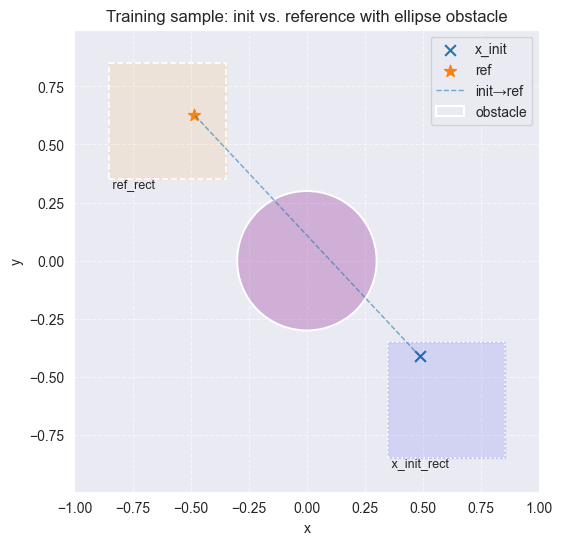

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Training sample: init vs. reference with ellipse obstacle'}, xlabel='x', ylabel='y'>)

In [26]:
# plotting a data sample from train loader
plot_training_sample_with_ellipse(
    train_loader,
    sample_idx=34,
    pos_idx=(0, 2),
    init_rect=init_rect,
    ref_rect=ref_rect,
    xmin=-1., xmax=1.
)

#### Defining the ODE object for controller training

In [27]:
import torch
import torch.nn as nn
from neuromancer.dynamics.ode import ODESystem

class DoubleIntegrator2DParam(ODESystem):
    def __init__(self, insize=6, outsize=4):
        """
        2D mass–spring–damper (double integrator with optional damping/stiffness).

        insize = 6  -> concatenation of state and input: [x, xdot, y, ydot, ux, uy]
        outsize = 4 -> state derivatives:                [xdot, xddot, ydot, yddot]
        """
        super().__init__(insize=insize, outsize=outsize)
        # learnable parameters (per-axis)
        self.mx = nn.Parameter(torch.tensor([1.0]), requires_grad=True)
        self.my = nn.Parameter(torch.tensor([1.0]), requires_grad=True)
        self.cx = nn.Parameter(torch.tensor([0.5]), requires_grad=True)
        self.cy = nn.Parameter(torch.tensor([0.5]), requires_grad=True)
        self.kx = nn.Parameter(torch.tensor([0.0]), requires_grad=True)
        self.ky = nn.Parameter(torch.tensor([0.0]), requires_grad=True)

    def ode_equations(self, x, u):
        """
        x: (..., 4) = [x, xdot, y, ydot]
        u: (..., 2) = [ux, uy]
        returns (..., 4): [xdot, xddot, ydot, yddot]
        """
        # states
        px = x[:, [0]]
        vx = x[:, [1]]
        py = x[:, [2]]
        vy = x[:, [3]]

        # inputs (clip similar to sample style; adjust bounds as needed)
        ux = torch.clip(u[:, [0]], min=-1.0, max=1.0)
        uy = torch.clip(u[:, [1]], min=-1.0, max=1.0)

        # dynamics
        dpx = vx
        dvx = -(self.cx / (self.mx + 1e-15)) * vx - (self.kx / (self.mx + 1e-15)) * px + (1.0 / (self.mx + 1e-15)) * ux

        dpy = vy
        dvy = -(self.cy / (self.my + 1e-15)) * vy - (self.ky / (self.my + 1e-15)) * py + (1.0 / (self.my + 1e-15)) * uy

        return torch.cat([dpx, dvx, dpy, dvy], dim=-1)


### Sparse Controller:

In [28]:
import importlib
import SparseDPC.trainer.problem
import SparseDPC.sindy.sindy
import SparseDPC.sindy.fx_library
importlib.reload(SparseDPC.trainer.problem)
importlib.reload(SparseDPC.sindy.sindy)
importlib.reload(SparseDPC.sindy.fx_library)
from SparseDPC.trainer.problem import SparsePolicyBuilder
from SparseDPC.sindy.sindy import SINDy
from SparseDPC.sindy.fx_library import fx_policy_library

double_integrator = DoubleIntegrator2DParam()
double_integrator.mx = nn.Parameter(torch.tensor(gt_model.mx), requires_grad=False)
double_integrator.my = nn.Parameter(torch.tensor(gt_model.my), requires_grad=False)
double_integrator.cx = nn.Parameter(torch.tensor(gt_model.cx), requires_grad=False)
double_integrator.cy = nn.Parameter(torch.tensor(gt_model.cy), requires_grad=False)
double_integrator.kx = nn.Parameter(torch.tensor(gt_model.kx), requires_grad=False)
double_integrator.ky = nn.Parameter(torch.tensor(gt_model.ky), requires_grad=False)

scale= 1.
pol_configs = {
    "l1_coef": 0.0002,
    "Q_con_obs": scale * 1e2,
    "Q_con_x": scale * 10.0,
    "Q_con_u": scale * 10.0,
    "Q_u": scale * 0.05,
    "Q_r": scale * 2,
    "Q_dx": scale * 0.0000,
    "Q_du": scale * 0.0001,
    "lr": 0.002,
    "epochs": 9999,
    "threshold": 0.08,
    "prune_every": 1000,
    "threshold_mult": 1.15,
    "prune_noise": 0.02
}
refstep=1
policies_seed = 0


In [29]:

import torch
import itertools
from typing import Callable, List

from SparseDPC.sindy.library import FunctionLibrary
from SparseDPC.sindy.sindy import SINDy

def fx_policy_library(
    nx: int,
    nref: int,
    policy_name: str,
    seed: int,
    device: torch.device
) -> SINDy:
    """
    Returns a symbolic policy model using mixed state-reference basis.

    Includes linear, trigonometric, and polynomial interactions between x and r.
    """
    theta_funs: List[Callable] = []
    theta_names: List[str] = []

    # x features
    for i in range(nx):
        theta_funs.append(lambda X, r, i=i: X[:, i])
        theta_names.append(f"x_{i}")

    # Pairwise x_i * x_j
    for i, j in itertools.combinations(range(nx), 2):
        theta_funs.append(lambda X, r, i=i, j=j: X[:, i] * X[:, j])
        theta_names.append(f"x_{i} * x_{j}")

    # r features
    for i in range(nref):
        theta_funs.append(lambda X, r, i=i: r[:, i])
        theta_names.append(f"r_{i}")

    # x_i * r_j terms
    for i in range(nx):
        for j in range(nref):
            theta_funs.append(lambda X, r, i=i, j=j: X[:, i] * r[:, j])
            theta_names.append(f"x_{i} * r_{j}")


    lib = FunctionLibrary(theta_funs, n_features=1, n_control=nref, function_names=theta_names)
    return SINDy(library=lib, policy_name=policy_name, seed=seed, device=device)

### Define Problem

### Optimization problem (built in `_build_problem`)

**Decision variables (over horizon)**
- $x \in \mathbb{R}^{T \times B \times n_x}$ (state)
- $u \in \mathbb{R}^{T \times B \times n_u}$ (control)
- $r \in \mathbb{R}^{T \times B \times 2}$ (reference)

Positions: $x_{\text{pos}} = x[..., [0,2]]$, Velocities: $x_{\text{vel}} = x[..., [1,3]]$.

---

### Objective terms (Σ form)

Let horizon indices $t=0,\dots,T$, batch $b=1,\dots,B$, controls $j=1,\dots,n_u$, and position dims $i\in\{x,y\}$.
Let the last $\rho=\texttt{refstep}$ steps be $\mathcal{T}_\rho=\{T-\rho+1,\dots,T\}$.
Weights: $Q_u, Q_r, Q_{dx}, Q_{du}, \lambda_{\ell_1}$.

- **Position tracking**

$$
J_{\text{track}}
= Q_r \sum_{b=1}^B \sum_{t \in \mathcal{T}_\rho} \sum_{i \in \{x,y\}}
\big(x_{t,b}^{(i)} - r_{t,b}^{(i)}\big)^2
$$

- **Terminal velocity (at $t=T$)**

$$
J_{\text{vel}}
= \tfrac{Q_r}{2} \sum_{b=1}^B \sum_{i \in \{\dot{x},\dot{y}\}}
\big(x_{T,b}^{(i)}\big)^2
$$

- **Control effort**

$$
J_{u}
= Q_u \sum_{b=1}^B \sum_{t=0}^{T} \sum_{j=1}^{n_u}
\big(u_{t,b}^{(j)}\big)^2
$$

- **State smoothing**

$$
J_{\Delta x}
= Q_{dx} \sum_{b=1}^B \sum_{t=1}^{T} \sum_{k=1}^{n_x}
\big(x_{t,b}^{(k)} - x_{t-1,b}^{(k)}\big)^2
$$

- **Control smoothing**

$$
J_{\Delta u}
= Q_{du} \sum_{b=1}^B \sum_{t=1}^{T} \sum_{j=1}^{n_u}
\big(u_{t,b}^{(j)} - u_{t-1,b}^{(j)}\big)^2
$$

- **Policy sparsity (per policy $k$)**

$$
J_{\ell_1} = \lambda_{\ell_1} \sum_{k=1}^{n_u} \|\theta_k\|_{1}
$$

- **Total objective**

$$
J = J_{\text{track}} + J_{\text{vel}} + J_{u} + J_{\Delta x} + J_{\Delta u} + J_{\ell_1}
$$

---

### Constraints (penalized)

- **Obstacle keep-out (ellipse):**
  $ b(x_1-c)^2 + (x_2-d)^2 \ge (p/2)^2 $
- **State bounds:** $x_{\min} \le x_{\text{pos}} \le x_{\max}$
- **Control bounds:** $u_{\min} \le u \le u_{\max}$

---

### Loss & training

- Objectives + constraints combined in `PenaltyLoss`.
- `Problem([system], loss)` links policy → integrator → trajectories → losses.
- Training via `AdamW`, `SparseTrainer` handles pruning (`threshold`, `prune_every`).


In [30]:
from __future__ import annotations
from typing import Dict, Sequence, List, Optional

import torch

import neuromancer.dynamics.ode as ode
from neuromancer.dynamics    import integrators as nm_int
from neuromancer.system     import Node, System
from neuromancer.loss       import PenaltyLoss
from neuromancer.problem    import Problem
from neuromancer.constraint import variable
from neuromancer.loggers    import BasicLogger

from SparseDPC.utils.integrator import OneElementEulerIntegrator
from SparseDPC.trainer.trainer   import SparseTrainer
#from SparseDPC.sindy.fx_library   import fx_policy_library
from SparseDPC.utils.integrator   import FullStateEulerIntegrator


class SparsePolicyBuilder2D:
    """
    """

    # ------------------------------- ctor ---------------------------------- #
    def __init__(
        self,
        *,
        fx_models: Sequence[torch.nn.Module],
        nx: int,
        nref: int,
        nu: int,
        ts: float,
        nsteps: int,
        train_loader,
        dev_loader,
        bounds: Dict[str, torch.Tensor | float],
        config: Dict[str, float | int],
        obstacle_configs: Dict[str, float | int],
        refstep: int = 2,
        seed: int,
        device: torch.device,
        is_sindy: bool = True,
        gt_model: Optional[ode.ODESystem] = None,
        logger=None                     # may be None –> call set_logger later
    ) -> None:

        self.device        = device
        self._config       = config           # stash for later
        self._train_loader = train_loader
        self._dev_loader   = dev_loader
        self._bounds       = bounds
        self._obstacle_configs = obstacle_configs

        # 0.  generate one policy block per input channel ------------------ #
        self.policies: List[torch.nn.Module] = [
            fx_policy_library(nx=nx, nref=nref,
                              policy_name=f"u_{k}",
                              seed=seed, device=device)
            for k in range(nu)
        ]

        # 1.  build system graph (policy → integrator) --------------------- #
        self._build_system(fx_models, ts, nsteps, bounds,
                           is_sindy=is_sindy, gt_model=gt_model)

        # 2.  objectives, constraints, Problem ---------------------------- #
        self._build_problem(bounds, config, obstacle_configs, refstep)

        # 3.  build trainer *IF* a logger is supplied ---------------------- #
        self.trainer = None
        if logger is not None:
            self.set_logger(logger)

        self.problem.show()

    # ====================================================================== #
    # internal helpers
    # ====================================================================== #

    def _build_system(
        self,
        fx_models: Sequence[torch.nn.Module],
        ts: float,
        nsteps: int,
        bounds,
        *,
        is_sindy: bool,
        gt_model: Optional[ode.ODESystem]
    ):
        umin, umax = bounds["umin"], bounds["umax"]

        policy_node = Node(
            lambda xn, r: torch.cat(
                [torch.clamp(fp(xn, r), umin, umax) for fp in self.policies],
                dim=-1
            ),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

        integ = (FullStateEulerIntegrator(fx_models, ts)
                 if is_sindy else
                 nm_int.Euler(gt_model, h=torch.tensor(ts)))

        integ_node = Node(integ, ['xn', 'u'], ['xn'], name="x_integrator")
        self.system = System([policy_node, integ_node], nsteps=nsteps)

    def _build_problem(self, bounds, cfg, obstacle_cfg, refstep):

        xmin, xmax = bounds["xmin"], bounds["xmax"]
        x   = variable('xn')        # states over horizon, shape: (T, B, nx)
        u   = variable('u')         # controls over horizon, shape: (T, B, nu)
        ref = variable('r')         # references, shape: (T, B, 2)  -> [x_ref, y_ref]

        # select positions from state to compare against ref
        x_pos = x[:, :, [0, 2]]
        x_vel = x[:, :, [1, 3]]
        x1 = variable('xn')[:, :, [0]]
        x2 = variable('xn')[:, :, [2]]

        # losses
        action_loss       = cfg["Q_u"]  * ((u == 0.0)          ^ 2)   # control penalty
        reference_loss_position    = cfg["Q_r"]  * ((ref[:, -refstep:, :]==x_pos[:, -refstep:, :])    ^ 2)   # track [x,y]
        reference_loss_velocity    = cfg["Q_r"]/2  * ((x_vel[:, -1:, :] == 0.0)    ^ 2)
        state_smoothing   = cfg["Q_dx"] * ((x[:, 1:, :] == x[:, :-1, :] ) ^ 2)   # Δx penalty
        control_smoothing = cfg["Q_du"] * ((u[:, 1:, :] == u[:, :-1, :] ) ^ 2)   # Δu penalty


        l1_terms = []
        for k, fp in enumerate(self.policies):
            l1_raw = variable([x],
                              lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                              display_name=f"l1_pol{k}")
            l1_pen = cfg["l1_coef"] * (l1_raw == 0)
            l1_pen.name = f"loss_l1_pol{k}"
            l1_terms.append(l1_pen)

        objectives = [reference_loss_position, reference_loss_velocity, action_loss, state_smoothing, control_smoothing]

        for n, nm in zip(objectives,
                         ["reference_loss_position", "reference_loss_velocity", "action_loss", "state_smoothing", "control_smoothing"]):
            n.name = nm

        #Contraints
        p = obstacle_cfg["p"] ; b = obstacle_cfg["b"] ; c = obstacle_cfg["c"]; d = obstacle_cfg["d"]
        constraints = [
            cfg["Q_con_obs"]  * ( (p / 2) ** 2 <= (b * (x1 - c) ** 2 + (x2 - d) ** 2)),
            cfg["Q_con_x"] * (x_pos > xmin),                      # lower
            cfg["Q_con_x"] * (x_pos < xmax),                      # upper
            cfg["Q_con_u"] * (u < umax),                      # lower
            cfg["Q_con_u"] * (u > umin),                      # upper

        ]
        for n, nm in zip(constraints,
                         ["obstacle_pen", "x_min", "x_max", "u_min", "u_max"]):
            n.name = nm

        loss = PenaltyLoss([*objectives, *l1_terms], constraints)
        self.problem = Problem([self.system], loss)

    def _instantiate_trainer(self, logger):
        cfg = self._config
        lr  = cfg["lr"]
        opts = [torch.optim.AdamW(fp.parameters(), lr=lr)
                for fp in self.policies]

        self.trainer = SparseTrainer(
            problem       = self.problem,
            fx_models     = self.policies,
            lr            = lr,
            train_data    = self._train_loader,
            dev_data      = self._dev_loader,
            optimizers    = opts,
            epochs        = cfg["epochs"],
            train_metric  = 'train_loss',
            eval_metric   = 'dev_loss',
            logger        = logger,
            device        = self.device,
            threshold     = cfg["threshold"],
            prune_every   = cfg["prune_every"],
            threshold_mult= cfg["threshold_mult"],
            prune_noise   = cfg["prune_noise"]
        )

    # ====================================================================== #
    # public API
    # ====================================================================== #

    def set_logger(self, logger):
        """
        Plug-in a logger **after** the builder has been created.
        If a trainer already exists it will be replaced.
        """
        self._instantiate_trainer(logger)

    def train(self):
        if self.trainer is None:
            raise RuntimeError("Logger not set → trainer not built. "
                               "Call `set_logger(logger)` first.")
        best_state = self.trainer.train()
        self.trainer.model.load_state_dict(best_state)
        return best_state



In [31]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=2, add_sqrt=False, add_u_prod=False) for i in range(nx)]
# Print model structures
for fx in fx_models:
    print(fx)


import os, glob, torch

run_id = 1
models_dir = f"results/tests/dynamics/run_{run_id}/saved_models"   # change root here

for i, model in enumerate(fx_models):
    pattern = os.path.join(models_dir, f"trained_dynamics_x{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for x{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded x{i} from {os.path.basename(ckpt)}")

dx0/dt = -0.000*x0 + 0.027*x1 + -0.041*x2 + -0.037*x3 + -0.019*x0^2 + 0.013*x0*x1 + -0.001*x0*x2 + 0.040*x0*x3 + -0.004*x1^2 + 0.013*x1*x2 + -0.015*x1*x3 + -0.010*x2^2 + -0.048*x2*x3 + -0.033*x3^2 + -0.021*u_0 + 0.002*u_1 + 0.020*x0*u_0 + 0.030*x1*u_0 + -0.034*x2*u_0 + -0.022*x3*u_0 + 0.018*x0*u_1 + 0.042*x1*u_1 + -0.010*x2*u_1 + 0.037*x3*u_1

dx1/dt = -0.000*x1 + 0.027*x0 + -0.041*x2 + -0.037*x3 + -0.019*x0^2 + 0.013*x0*x1 + -0.001*x0*x2 + 0.040*x0*x3 + -0.004*x1^2 + 0.013*x1*x2 + -0.015*x1*x3 + -0.010*x2^2 + -0.048*x2*x3 + -0.033*x3^2 + -0.021*u_0 + 0.002*u_1 + 0.020*x0*u_0 + 0.030*x1*u_0 + -0.034*x2*u_0 + -0.022*x3*u_0 + 0.018*x0*u_1 + 0.042*x1*u_1 + -0.010*x2*u_1 + 0.037*x3*u_1

dx2/dt = -0.000*x2 + 0.027*x0 + -0.041*x1 + -0.037*x3 + -0.019*x0^2 + 0.013*x0*x1 + -0.001*x0*x2 + 0.040*x0*x3 + -0.004*x1^2 + 0.013*x1*x2 + -0.015*x1*x3 + -0.010*x2^2 + -0.048*x2*x3 + -0.033*x3^2 + -0.021*u_0 + 0.002*u_1 + 0.020*x0*u_0 + 0.030*x1*u_0 + -0.034*x2*u_0 + -0.022*x3*u_0 + 0.018*x0*u_1 + 0.042*x

None


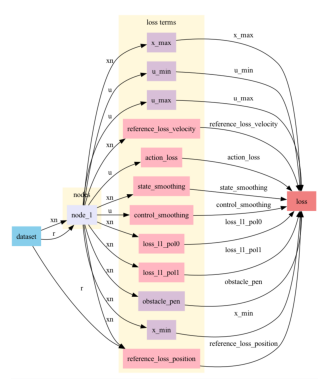

In [35]:
builder_SD_SINDy = SparsePolicyBuilder2D(
    fx_models     = fx_models,
    is_sindy      = True,
    gt_model      = None,
    nx            = nx,
    nref          = 2,
    nu            = nu,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    obstacle_configs = ellipse_configs,
    refstep = refstep,
    seed          = policies_seed,
    device        = device,
    logger        = BasicLogger(args=None, savedir='runs', verbosity=1,
                                stdout=['dev_loss', 'train_loss'])
)

In [36]:
for fp in builder_SD_SINDy.policies:
    print(fp)

u_0 = -0.000*x_0 + 0.027*x_1 + -0.041*x_2 + -0.037*x_3 + -0.019*x_0 * x_1 + 0.013*x_0 * x_2 + -0.001*x_0 * x_3 + 0.040*x_1 * x_2 + -0.004*x_1 * x_3 + 0.013*x_2 * x_3 + -0.015*r_0 + -0.010*r_1 + -0.048*x_0 * r_0 + -0.033*x_0 * r_1 + -0.021*x_1 * r_0 + 0.002*x_1 * r_1 + 0.020*x_2 * r_0 + 0.030*x_2 * r_1 + -0.034*x_3 * r_0 + -0.022*x_3 * r_1

u_1 = -0.000*x_0 + 0.027*x_1 + -0.041*x_2 + -0.037*x_3 + -0.019*x_0 * x_1 + 0.013*x_0 * x_2 + -0.001*x_0 * x_3 + 0.040*x_1 * x_2 + -0.004*x_1 * x_3 + 0.013*x_2 * x_3 + -0.015*r_0 + -0.010*r_1 + -0.048*x_0 * r_0 + -0.033*x_0 * r_1 + -0.021*x_1 * r_0 + 0.002*x_1 * r_1 + 0.020*x_2 * r_0 + 0.030*x_2 * r_1 + -0.034*x_3 * r_0 + -0.022*x_3 * r_1



In [40]:
builder_SD_SINDy.train()

epoch: 34	train_loss: 0.06151	dev_loss: 0.05512	eltime:  6606.22647
epoch: 35	train_loss: 0.05973	dev_loss: 0.05353	eltime:  6611.16026
Training interrupted.


{}

### Test on test data

In [38]:
def make_test_sample(
    *,
    nx: int,
    nsteps: int,
    device: torch.device,
    ellipse: Dict[str, float],     # {"p":..., "b":..., "c":..., "d":...}
    seed: int = 7,
    init_vel_std: float = 0.0,     # e.g., 0.05 for a bit of initial motion
    # Rectangles: ((x_min, y_min), (x_max, y_max))
    init_rect: Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
    ref_rect:  Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, -1.0), (1.0, 1.0)),
) -> Dict[str, torch.Tensor]:
    """
    Returns a dict for closed-loop rollouts:
        data = {"xn": (1,1,nx), "r": (1,nsteps+1,2)}
    - (x,y) for the initial state is sampled UNIFORMLY within init_rect, but OUTSIDE the ellipse.
    - Reference (x_ref,y_ref) is sampled UNIFORMLY within ref_rect, also OUTSIDE the ellipse,
      and repeated across time.
    - No margins or extra clearance.
    """
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    # Ellipse parameters
    p = float(ellipse["p"]); b = float(ellipse["b"])
    c = float(ellipse["c"]); d = float(ellipse["d"])
    assert b > 0.0 and p >= 0.0

    def outside_ellipse_np(x: np.ndarray, y: np.ndarray) -> np.ndarray:
        # True if (x,y) is OUTSIDE the ellipse b(x-c)^2 + (y-d)^2 = (p/2)^2
        return (b * (x - c) ** 2 + (y - d) ** 2) >= (0.5 * p) ** 2

    def _ordered_rect(rect: Tuple[Tuple[float, float], Tuple[float, float]]):
        (x0, y0), (x1, y1) = rect
        if x1 < x0: x0, x1 = x1, x0
        if y1 < y0: y0, y1 = y1, y0
        if not (x1 > x0 and y1 > y0):
            raise ValueError("Rectangle must have positive width and height.")
        return x0, y0, x1, y1

    def sample_xy_in_rect_outside(rect: Tuple[Tuple[float, float], Tuple[float, float]],
                                  max_tries: int = 200_000,
                                  block: int = 4096) -> Tuple[float, float]:
        x0, y0, x1, y1 = _ordered_rect(rect)
        tries = 0
        while tries < max_tries:
            m = min(block, max_tries - tries)
            xs = rng.uniform(x0, x1, size=m)
            ys = rng.uniform(y0, y1, size=m)
            keep = outside_ellipse_np(xs, ys)
            if np.any(keep):
                # take the first valid point
                idx = np.nonzero(keep)[0][0]
                return float(xs[idx]), float(ys[idx])
            tries += m
        raise RuntimeError(
            "Could not sample a valid (x,y) outside the ellipse within the given rectangle. "
            "Adjust the rectangle or ellipse parameters."
        )

    # --- Initial state (x,y) sampled in init_rect but OUTSIDE ellipse ---
    x0, y0 = sample_xy_in_rect_outside(init_rect)
    xn = torch.zeros((1, 1, nx), dtype=torch.float32, device=device)
    # positions (assumes indices 0 and 2 are x,y)
    xn[:, :, 0] = x0
    if nx >= 3:
        xn[:, :, 2] = y0
    # optional small initial velocities (indices 1 and 3 if present)
    if nx >= 2 and init_vel_std > 0:
        xn[:, :, 1] = torch.randn(1, 1, device=device) * init_vel_std
    if nx >= 4 and init_vel_std > 0:
        xn[:, :, 3] = torch.randn(1, 1, device=device) * init_vel_std

    # --- Constant reference (x_ref,y_ref) sampled in ref_rect but OUTSIDE ellipse ---
    xr, yr = sample_xy_in_rect_outside(ref_rect)
    r = torch.zeros((1, nsteps + 1, 2), dtype=torch.float32, device=device)
    r[:, :, 0] = xr
    r[:, :, 1] = yr

    return {"xn": xn, "r": r}


import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_trajectories_with_ellipse(
    traj_list: list[dict],
    r: torch.Tensor | np.ndarray,
    *,
    p: float,
    b: float,
    c: float,
    d: float,
    batch_idx: int = 0,
    xmin: float = -1.0,
    xmax: float = 1.0,
    title: str = "Closed-loop trajectories with keep-out ellipse",
    show_ref_path: bool = True,
):
    """
    Plots XY paths from multiple simulated trajectories plus the keep-out ellipse.

    Parameters
    ----------
    traj_list : list of dicts
        Each dict must contain:
          - "traj": (B, T, nx) tensor/array with states
          - "label": str for legend
        Optional:
          - "color": matplotlib color
          - "linestyle": e.g. "-", "--"
          - "alpha": float
    r : (B, T, 2) reference positions over time
    p, b, c, d : ellipse parameters
    batch_idx : which batch index to plot
    """

    # convert reference to numpy
    if isinstance(r, torch.Tensor):
        r = r.detach().cpu().numpy()
    R = r[batch_idx]  # (T, 2)
    xr, yr = R[:, 0], R[:, 1]

    # ellipse radii
    if b <= 0.0 or p < 0.0:
        raise ValueError("Require b > 0 and p >= 0 for a valid ellipse.")
    a_x = (p * 0.5) / np.sqrt(b)
    a_y = (p * 0.5)

    fig, ax = plt.subplots(figsize=(6, 6))

    # plot each trajectory
    for cfg in traj_list:
        X = cfg["traj"]
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
        X = X[batch_idx]  # (T, nx)

        if X.shape[1] < 3:
            raise ValueError("Expected nx>=3 with positions at indices 0 (x) and 2 (y).")

        xs, ys = X[:, 0], X[:, 2]
        color     = cfg.get("color", None)
        linestyle = cfg.get("linestyle", "-")
        alpha     = cfg.get("alpha", 1.0)
        label     = cfg.get("label", "trajectory")

        ax.plot(xs, ys, lw=1.5, color=color, linestyle=linestyle,
                alpha=alpha, label=label)

        ax.scatter([xs[-1]], [ys[-1]], c=color, marker="*", s=120)
    ax.scatter([xs[0]], [ys[0]], c="green", marker="x", s=80, label="start point")
    # optional reference path
    if show_ref_path:
        ax.scatter([xr[-1]], [yr[-1]], c="purple", marker="o", s=60,
                   label="reference")

    # ellipse (fill + edge)
    ell_fill = Ellipse((c, d), width=2 * a_x, height=2 * a_y,
                       facecolor="tab:purple", edgecolor="none", alpha=0.5)
    ax.add_patch(ell_fill)
    ell_edge = Ellipse((c, d), width=2 * a_x, height=2 * a_y,
                       fill=False, edgecolor="tab:purple", lw=1, alpha=0.6,
                       label="obstacle")
    ax.add_patch(ell_edge)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(True, linestyle="--", alpha=0.6)

    # limits
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.legend(loc="best")
    plt.show()
    return fig, ax



#### Rollout on test sample

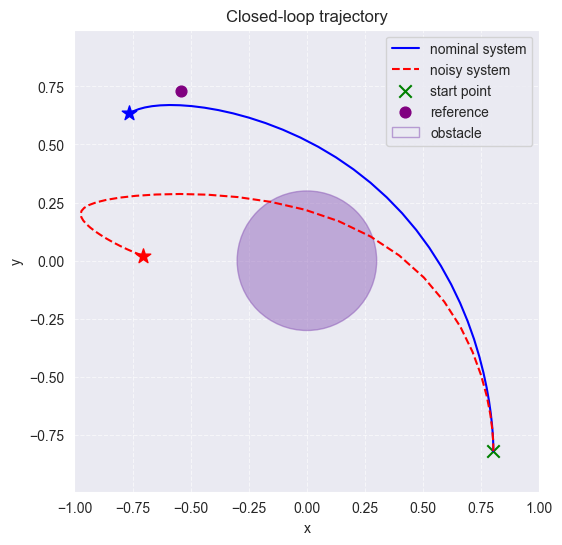

In [39]:
# Closed-loop simulation setup
nsteps_test = nsteps
data = make_test_sample(
    nx=4, nsteps=nsteps_test, seed= 31
    , device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)


double_integrator_noisy = DoubleIntegrator2DParam()
double_integrator_noisy.mx = nn.Parameter(torch.tensor(gt_model.mx - 0.5), requires_grad=False)
double_integrator_noisy.cx = nn.Parameter(torch.tensor(gt_model.cx - 0.1), requires_grad=False)
double_integrator_noisy.my = nn.Parameter(torch.tensor(gt_model.my - 0.5), requires_grad=False)
double_integrator_noisy.cy = nn.Parameter(torch.tensor(gt_model.cy - 0.1), requires_grad=False)


gt_integrator = integrators.Euler(double_integrator, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

gt_integrator_noisy = integrators.Euler(double_integrator_noisy, h=torch.tensor(ts))
gt_integrator_node_noisy = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')


policy_node = Node(
            lambda xn, r: torch.cat(
                [torch.clamp(fp(xn, r), umin, umax) for fp in builder_SD_SINDy.policies],
                dim=-1
            ),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )
# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy_system = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy_system_noisy = copy.deepcopy(System([policy_node, gt_integrator_node_noisy]))

# Simulate system
gt_sindy_policy_system.nsteps = nsteps_test
gt_sindy_policy_system_noisy.nsteps = nsteps_test

trajectories = gt_sindy_policy_system(data)
trajectories_noisy = gt_sindy_policy_system_noisy(data)

traj_x = trajectories["xn"]
traj_r = trajectories['r']

traj_x_noisy = trajectories_noisy["xn"]
traj_r_noisy = trajectories_noisy['r']

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "nominal system", "color": "blue"},
        {"traj": traj_x_noisy,   "label": "noisy system",   "color": "red", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)


#### Save the sparse policy:

In [304]:
# --------------------------------------------------------------------------- #
# INLINE SNAPSHOT (mapped .pt + raw-policy JSON)
# --------------------------------------------------------------------------- #
import os, json, numpy as np, torch
from pathlib import Path
from SparseDPC.sindy.fx_library import fx_policy_library
from SparseDPC.utils.utils       import map_to_new_fx, save_model_with_timestamp

# ---------------- user-supplied objects & constants ------------------------ #
builders       = {"SINDy": builder_SD_SINDy}   # tag → builder
base_dir       = "results/tests/sparse"
# --------------------------------------------------------------------------- #

# 1. auto-increment parent run directory
run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(pol_configs, indent=4)))

# 2. iterate over builders
for tag, bld in builders.items():
    tag_dir    = run_dir / tag;          tag_dir.mkdir()
    models_dir = tag_dir / "saved_models"; models_dir.mkdir()

    for i in range(nu):
        # ---- prepare *mapped* model to full library & save .pt ----------
        full_lib   = fx_policy_library(nx=nx, nref=2,
                                       policy_name=f"u_{i}",
                                       seed=policies_seed,
                                       device=bld.device)
        mapped_pol = map_to_new_fx(bld.policies[i], full_lib)
        save_model_with_timestamp(mapped_pol,
                                  f"trained_policy_{i}",
                                  models_dir)

        # ---- JSON log of the *trained (pruned) policy* ------------------
        orig_pol = bld.policies[i]
        coef   = orig_pol.coef.detach().cpu().numpy().flatten().tolist()
        fnames = orig_pol.library.function_names
        expr   = str(orig_pol)

        log_entry = {
            "function_names": fnames,
            "coef":           coef,
            "active_terms":   int(np.count_nonzero(coef)),
            "expr":           expr
        }
        with open(tag_dir / f"policy{i}_log.json", "w") as f:
            json.dump(log_entry, f, indent=2)

print(f"✓  results saved under  {run_dir.as_posix()}")


✅ Model saved to results/tests/sparse/run_1/SINDy/saved_models/trained_policy_0_20250903_122130.pth
✅ Model saved to results/tests/sparse/run_1/SINDy/saved_models/trained_policy_1_20250903_122130.pth
✓  results saved under  results/tests/sparse/run_1


#### Training the neural network policy

In [125]:
nn_config = {
    "layers": [32, 64, 32],
    "reg_coef": 20.0,
    "const_coef": 20.0,
    "lr": 0.001,
    "epochs": 5000,
    "warmup": 200,
    "patience": 100,
}

scale = 1.
pol_configs = {
    "l1_coef": 0.008,
    "Q_con_obs": scale * 1e2,
    "Q_con_x": scale * 10.0,
    "Q_con_u": scale * 10.0,
    "Q_u": scale * 0.05,
    "Q_r": scale * 2,
    "Q_dx": scale * 0.0000,
    "Q_du": scale * 0.0001,
}
refstep=1

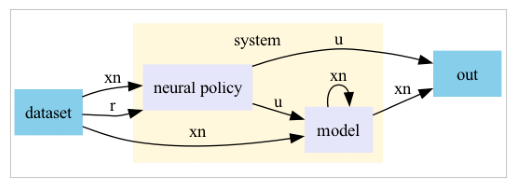

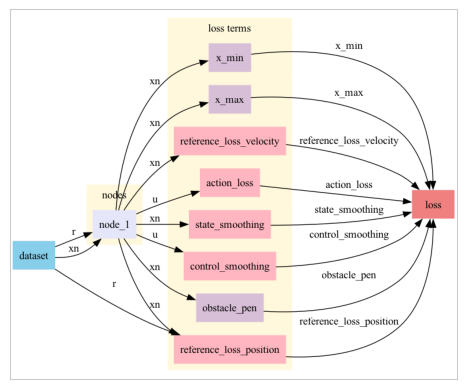

None
Number of parameters: 4482
************   training with 40 steps   ************   


/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 40, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0	train_loss: 1.55786	dev_loss: 1.51529	eltime:  1.09499
epoch: 10	train_loss: 0.18464	dev_loss: 0.18383	eltime:  9.09824
epoch: 20	train_loss: 0.02985	dev_loss: 0.02799	eltime:  16.68873
epoch: 30	train_loss: 0.01669	dev_loss: 0.01626	eltime:  24.28461
epoch: 40	train_loss: 0.01379	dev_loss: 0.01348	eltime:  32.32537
epoch: 50	train_loss: 0.01245	dev_loss: 0.01216	eltime:  40.16162
epoch: 60	train_loss: 0.01164	dev_loss: 0.01144	eltime:  48.01860
epoch: 70	train_loss: 0.01103	dev_loss: 0.01084	eltime:  55.86741
epoch: 80	train_loss: 0.01045	dev_loss: 0.01030	eltime:  63.47938
epoch: 90	train_loss: 0.00992	dev_loss: 0.00979	eltime:  71.39559
epoch: 100	train_loss: 0.00944	dev_loss: 0.00930	eltime:  79.24167
epoch: 110	train_loss: 0.00899	dev_loss: 0.00890	eltime:  87.36924
epoch: 120	train_loss: 0.00858	dev_loss: 0.00856	eltime:  94.99918
epoch: 130	train_loss: 0.00821	dev_loss: 0.00828	eltime:  102.78450
Interrupted training loop.
Total Training time:  105.95300817489624


In [270]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.trainer import Trainer
import time
# reuse the SAME policy network on mirrored inputs
net_sindy = blocks.MLP_bounds(insize=nx + 2, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)

# # neural net control policy with hard control action bounds
policy_neural_sindy = Node(net_sindy, ['xn', 'r'], ['u'], name='neural policy')
gt_integrator = integrators.Euler(double_integrator, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')
neural_sindy_system = System([policy_neural_sindy, gt_integrator_node ], nsteps=nsteps)
neural_sindy_system.show()

# variables
x   = variable('xn')        # states over horizon, shape: (T, B, nx)
u   = variable('u')         # controls over horizon, shape: (T, B, nu)
ref = variable('r')         # references, shape: (T, B, 2)  -> [x_ref, y_ref]

# select positions from state to compare against ref
x_pos = x[:, :, [0, 2]]
x_vel = x[:, :, [1, 3]]
x1 = variable('xn')[:, :, [0]]
x2 = variable('xn')[:, :, [2]]

# losses
action_loss       = pol_configs["Q_u"]  * ((u == 0.0)          ^ 2)   # control penalty
reference_loss_position    = pol_configs["Q_r"]  * ((ref[:, -refstep:, :]==x_pos[:, -refstep:, :])    ^ 2)   # track [x,y]
reference_loss_velocity    = pol_configs["Q_r"]/2  * ((x_vel[:, -1:, :] == 0.0)    ^ 2)
state_smoothing   = pol_configs["Q_dx"] * ((x[:, 1:, :] == x[:, :-1, :] ) ^ 2)   # Δx penalty
control_smoothing = pol_configs["Q_du"] * ((u[:, 1:, :] == u[:, :-1, :] ) ^ 2)   # Δu penalty

objectives = [reference_loss_position, reference_loss_velocity, action_loss, state_smoothing, control_smoothing]

for n, nm in zip(objectives,
                 ["reference_loss_position", "reference_loss_velocity", "action_loss", "state_smoothing", "control_smoothing"]):
    n.name = nm

#Contraints
p = ellipse_configs["p"] ; b = ellipse_configs["b"] ; c = ellipse_configs["c"]; d = ellipse_configs["d"]
constraints = [
    pol_configs["Q_con_obs"]  * (   (p / 2) ** 2 < (b * (x1 - c) ** 2 + (x2 - d) ** 2)  ),
    pol_configs["Q_con_x"] * (x_pos > xmin),                      # lower
    pol_configs["Q_con_x"] * (x_pos < xmax),                      # upper
]
for n, nm in zip(constraints,
                 ["obstacle_pen", "x_min", "x_max", "y_N_min", "y_N_max"]):
    n.name = nm

# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_k+1)
components = [neural_sindy_system]
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem(components, loss)
# plot computational graph
problem.show()

optimizer = torch.optim.AdamW(policy_neural_sindy.parameters(), lr=0.001)
logger_NN_SINDy = BasicLogger(args=None, savedir='test', verbosity=10,
                        stdout=['dev_loss', 'train_loss'])
#  Neuromancer trainer
trainer = Trainer(
    problem,
    None,
    None,
    optimizer=optimizer,
    epochs=nn_config["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=nn_config["warmup"],
    patience=nn_config["patience"],
    logger=logger_NN_SINDy
)

print(f'************   training with {nsteps} steps   ************   ')
trainer.train_data, trainer.dev_data = train_loader, dev_loader
trainer.problem = problem
start_time = time.time()

# Train control policy
best_model = trainer.train()

# load best trained model
end_time = time.time()
total_time_NN_SINDy = end_time - start_time

print("Total Training time: ", total_time_NN_SINDy)

In [271]:
# Closed-loop simulation setup
gt_integrator = integrators.Euler(double_integrator, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy = copy.deepcopy(System([policy_neural_sindy, gt_integrator_node]))
gt_sindy_policy.show()

# Simulate system
nsteps_test = nsteps
gt_sindy_policy.nsteps = nsteps_test

seed = 47
data = make_test_sample(
    nx=4, nsteps=nsteps_test, seed= seed, device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)
# double_integrator.mx = nn.Parameter(torch.tensor([0.1]))
# double_integrator.my = nn.Parameter(torch.tensor([0.1]))
trajectories = gt_sindy_policy(data)

traj_x = trajectories["xn"]
traj_r = trajectories['r']

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_result_with_ellipse(
    x_traj=traj_x, r=traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)



KeyboardInterrupt



In [ ]:
# For checking the value of each constraint loss and objective loss



# # --- 1) Build Variables that read from trajectory dict ---
# from neuromancer import variable
#
#
# # variables
# x   = variable('xn')        # states over horizon, shape: (T, B, nx)
# u   = variable('u')         # controls over horizon, shape: (T, B, nu)
# ref = variable('r')         # references, shape: (T, B, 2)  -> [x_ref, y_ref]
#
# # select positions from state to compare against ref
# x_pos = x[:, :, [0, 2]]
# x_vel = x[:, :, [1, 3]]
# x1 = variable('xn')[:, :, [0]]
# x2 = variable('xn')[:, :, [2]]
#
# # losses
# action_loss       = pol_configs["Q_u"]  * ((u == 0.0)          ^ 2)   # control penalty
# reference_loss_position    = pol_configs["Q_r"]  * ((ref[:, -refstep:, :]==x_pos[:, -refstep:, :])    ^ 2)   # track [x,y]
# reference_loss_velocity    = pol_configs["Q_r"]  * ((x_vel[:, -1:, :] == 0.0)    ^ 2)
# state_smoothing   = pol_configs["Q_dx"] * ((x[:, 1:, :] == x[:, :-1, :] ) ^ 2)   # Δx penalty
# control_smoothing = pol_configs["Q_du"] * ((u[:, 1:, :] == u[:, :-1, :] ) ^ 2)   # Δu penalty
#
# objectives = [reference_loss_position, reference_loss_velocity, action_loss, state_smoothing, control_smoothing]
#
# for n, nm in zip(objectives,
#                  ["reference_loss_position", "reference_loss_velocity", "action_loss", "state_smoothing", "control_smoothing"]):
#     n.update_name(nm)
#
# #Contraints
# p = ellipse_configs["p"] ; b = ellipse_configs["b"] ; c = ellipse_configs["c"]; d = ellipse_configs["d"]
# constraints = [
#     pol_configs["Q_con_obs"]  * ( ((p / 2) ** 2 < (b * (x1 - c) ** 2 + (x2 - d) ** 2)) ^2),
#     pol_configs["Q_con_x"] * (x_pos > xmin),                      # lower
#     pol_configs["Q_con_x"] * (x_pos < xmax),                      # upper
# ]
# for n, nm in zip(constraints,
#                  ["obstacle_pen", "x_min", "x_max", "y_N_min", "y_N_max"]):
#     n.update_name(nm)
#
# # --- 4) Evaluate on your rollout and print values ---
# # NeuroMANCER nodes/constraints expect a dict keyed by Variable keys
# inp = {
#     'xn': traj_x,   # from trajectories
#     'r' : traj_r,
#     'u' : trajectories['u'],  # ensure your System returns 'u'; otherwise compute u via your policy separately
# }
#
# def show_term(term):
#     out = term(inp)
#     # out has three entries: term.name (weighted loss), f'{name}_value', f'{name}_violation'
#     wloss     = out[term.name]                     # scalar (mean over violation)
#     raw_value = out[f"{term.name}_value"]          # signed residual before hinge
#     violate   = out[f"{term.name}_violation"]      # post-hinge (and squared if ^2)
#     print(f"\n=== {term.name} ===")
#     print(f"weighted loss: {wloss.item():.6f}")
#     # Summaries over batch/time (adjust as you like)
#     print(f"value:    min {raw_value.min().item():.6f}, max {raw_value.max().item():.6f}, mean {raw_value.mean().item():.6f}")
#     print(f"violation min {violate.min().item():.6f}, max {violate.max().item():.6f}, mean {violate.mean().item():.6f}")
#
# print("\n--- OBJECTIVES ---")
# for term in objectives:
#     show_term(term)
#
# print("\n--- CONSTRAINTS ---")
# for term in constraints:
#     show_term(term)


### Solve with IPOPT

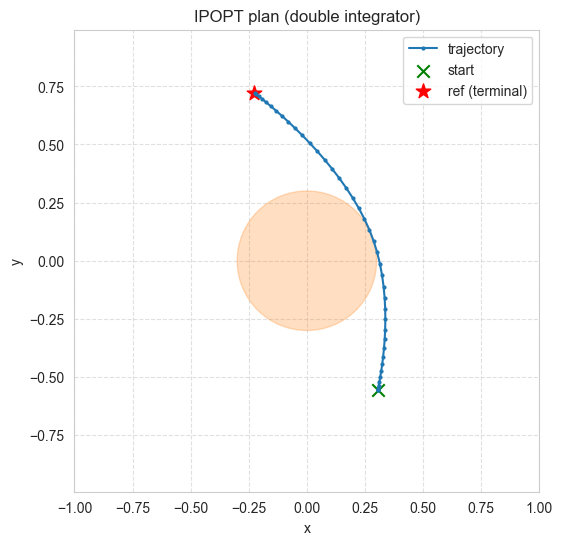

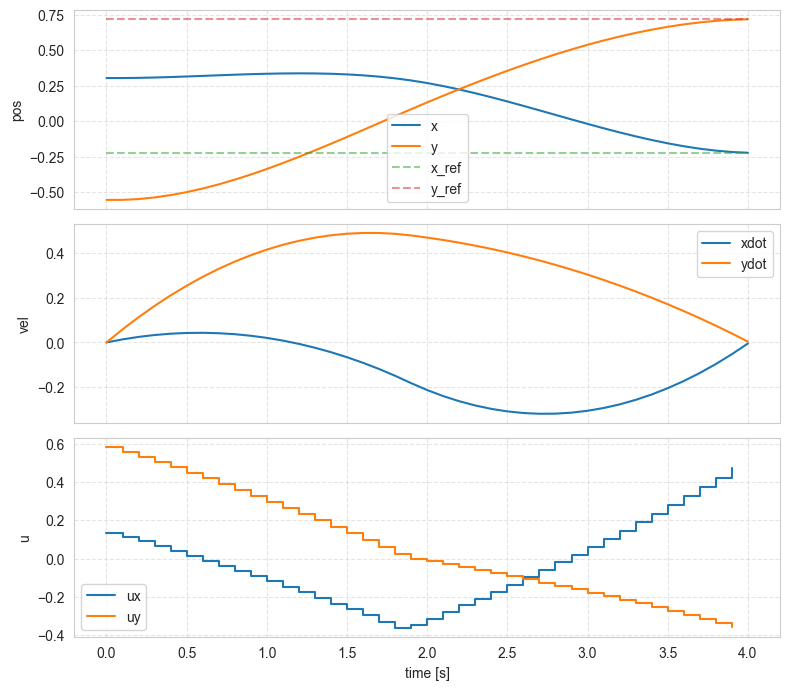

In [39]:
import numpy as np
import casadi as ca
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def solve_and_plot_ipopt(
    sample: dict,
    pol_configs: dict,
    *,
    ts: float,
    ellipse_cfg: dict | None = None,
    bounds: dict | None = None,
    # dynamics options
    use_msd: bool = False,     # True → mass–spring–damper; False → double integrator
    m: float = 1.0,
    k: float = 0.0,
    c: float = 0.0,
    # objective shaping
    track_whole_horizon: bool = True,   # True → track ref along horizon; False → terminal-only
    refstep: int = 1,
    add_state_smoothing: bool = True,
    add_control_smoothing: bool = True,
    title_xy: str = "IPOPT trajectory with keep-out ellipse",
):
    """
    Solve min_u J s.t. X_{k+1} = X_k + ts * f(X_k, U_k), and plot results.

    States: [x, xdot, y, ydot]
    Inputs: [ux, uy]
    sample['xn']: (1,1,4)
    sample['r'] : (1,N+1,2)  (# positions only, repeated across horizon in your data)
    """
    # -------------------- unpack data --------------------
    assert 'xn' in sample and 'r' in sample, "sample must have 'xn' and 'r'"
    x0 = sample['xn'][0, 0, :].detach().cpu().numpy()        # (4,)
    R  = sample['r'][0].detach().cpu().numpy()               # (N+1,2)
    N  = R.shape[0] - 1                                      # horizon length

    if ellipse_cfg is None:
        ellipse_cfg = dict(p=4.0, b=1.0, c=0.0, d=0.0)
    p = float(ellipse_cfg['p'])
    b = float(ellipse_cfg['b'])
    cC = float(ellipse_cfg['c'])
    dC = float(ellipse_cfg['d'])

    if bounds is None:
        bounds = dict(xmin=-2.0, xmax=2.0, umin=-1.0, umax=1.0)

    xmin = bounds['xmin']; xmax = bounds['xmax']
    umin = bounds['umin']; umax = bounds['umax']

    # weights
    Q_con_obs = float(pol_configs.get("Q_con_obs", 100.0))
    Q_con_x   = float(pol_configs.get("Q_con_x",   10.0))
    Q_u       = float(pol_configs.get("Q_u",        0.1))
    Q_r       = float(pol_configs.get("Q_r",        2.0))
    Q_dx      = float(pol_configs.get("Q_dx",       0.1))
    Q_du      = float(pol_configs.get("Q_du",       0.1))

    # -------------------- CasADi variables --------------------
    opti = ca.Opti()
    X = opti.variable(4, N+1)     # [x, xdot, y, ydot] over horizon
    U = opti.variable(2, N)       # [ux, uy] over horizon

    # -------------------- dynamics --------------------
    def f_cont(x, u):
        x_pos, x_dot, y_pos, y_dot = x[0], x[1], x[2], x[3]
        ux, uy = u[0], u[1]
        if not use_msd:
            ddx = ux / m
            ddy = uy / m
        else:
            ddx = (ux - c*x_dot - k*x_pos) / m
            ddy = (uy - c*y_dot - k*y_pos) / m
        return ca.vertcat(x_dot, ddx, y_dot, ddy)

    # Forward Euler discretization
    for k_step in range(N):
        xk = X[:, k_step]
        uk = U[:, k_step]
        xk_next = X[:, k_step+1]
        opti.subject_to(xk_next == xk + ts * f_cont(xk, uk))

    # Initial condition
    opti.subject_to(X[:, 0] == x0)

    # -------------------- bounds --------------------
    def to_arr(val, shape_len):
        if np.isscalar(val):
            return np.full(shape_len, float(val))
        arr = np.asarray(val, dtype=float)
        assert arr.shape == (shape_len,)
        return arr

    xmin_arr = to_arr(xmin, 4); xmax_arr = to_arr(xmax, 4)
    for i in range(4):
        opti.subject_to(opti.bounded(xmin_arr[i], X[i, :], xmax_arr[i]))

    umin_arr = to_arr(umin, 2); umax_arr = to_arr(umax, 2)
    for i in range(2):
        opti.subject_to(opti.bounded(umin_arr[i], U[i, :], umax_arr[i]))


    # -------------------- objective --------------------
    obj = 0

    # 1) tracking: positions only
    if track_whole_horizon:
        for k_step in range(N+1):
            rx, ry = R[k_step, 0], R[k_step, 1]
            obj += Q_r * ca.sumsqr(ca.vertcat(X[0, k_step]-rx, X[2, k_step]-ry))
    else:
        rxN, ryN = R[-1, 0], R[-1, 1]
        obj += Q_r * ca.sumsqr(ca.vertcat(X[0, -refstep:]-rxN, X[2, -refstep:]-ryN))

    obj += Q_r * ca.sumsqr(X[1, -1:])  # final xdot = 0
    obj += Q_r * ca.sumsqr(X[3, -1:])   # final ydot = 0
    # 2) effort
    obj += Q_u * ca.sumsqr(U)

    # 3) smoothing
    if add_state_smoothing and N >= 1:
        obj += Q_dx * ca.sumsqr(X[[0,2], 1:] - X[[0,2], :-1])
    if add_control_smoothing and N >= 2:
        obj += Q_du * ca.sumsqr(U[:, 1:] - U[:, :-1])

    # 4) obstacle keep-out (hinge^2): active only if INSIDE ellipse
    r2_boundary = (p*0.5)**2
    for k_step in range(N+1):
        xk, yk = X[0, k_step], X[2, k_step]
        r2 = b*(xk - cC)**2 + (yk - dC)**2
        violation = r2_boundary - r2                 # > 0 only when inside
        hinge = 0.5*(violation + ca.fabs(violation)) # ReLU
        obj += Q_con_obs * ca.sumsqr(hinge)

    # optional soft state box penalties (if desired)
    if Q_con_x > 0:
        obj += Q_con_x * ca.sumsqr(ca.fmax(0, (xmin_arr.reshape(-1,1) - X)))
        obj += Q_con_x * ca.sumsqr(ca.fmax(0, (X - xmax_arr.reshape(-1,1))))

    opti.minimize(obj)

    # -------------------- solver --------------------
    p_opts = {"print_time": False}
    s_opts = {"max_iter": 2000, "tol": 1e-6, "print_level": 0}
    opti.solver("ipopt", p_opts, s_opts)

    # Initial guess: straight line in position, zero inputs
    Xg = np.tile(x0.reshape(-1,1), (1, N+1))
    rxN, ryN = R[-1, 0], R[-1, 1]
    Xg[0, :] = np.linspace(x0[0], rxN, N+1)
    Xg[2, :] = np.linspace(x0[2], ryN, N+1)
    opti.set_initial(X, Xg)
    opti.set_initial(U, 0.0)

    sol = opti.solve()
    Xsol = np.array(sol.value(X))  # (4, N+1)
    Usol = np.array(sol.value(U))  # (2, N)
    J    = float(sol.value(obj))

    # -------------------- plotting --------------------
    # 1) XY with ellipse
    fig1, ax1 = plt.subplots(figsize=(6,6))
    # ellipse semi-axes from b*(x-c)^2 + (y-d)^2 = (p/2)^2
    a_x = (p*0.5)/np.sqrt(b)
    a_y = (p*0.5)
    ell = Ellipse((cC, dC), width=2*a_x, height=2*a_y, angle=0.0,
                  facecolor="tab:orange", edgecolor="tab:orange", alpha=0.25)
    ax1.add_patch(ell)
    ax1.plot(Xsol[0, :], Xsol[2, :], marker="o", markersize=2, linewidth=1.5, label="trajectory")
    ax1.scatter([Xsol[0, 0]], [Xsol[2, 0]], c="green", marker="x", s=80, label="start")
    ax1.scatter([R[-1,0]], [R[-1,1]], c="red", marker="*", s=120, label="ref (terminal)")
    ax1.set_title(title_xy)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.axis("equal"); ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.set_xlim(min(xmin if np.isscalar(xmin) else min(xmin), Xsol[0,:].min(), cC-1.5*a_x),
                 max(xmax if np.isscalar(xmax) else max(xmax), Xsol[0,:].max(), cC+1.5*a_x))
    ax1.set_ylim(min(xmin if np.isscalar(xmin) else min(xmin), Xsol[2,:].min(), dC-1.5*a_y),
                 max(xmax if np.isscalar(xmax) else max(xmax), Xsol[2,:].max(), dC+1.5*a_y))
    ax1.legend(loc="best")

    # 2) time-series of states and inputs
    t = np.arange(N+1)*ts
    fig2, axs = plt.subplots(3, 1, figsize=(8,7), sharex=True)
    axs[0].plot(t, Xsol[0, :], label="x"); axs[0].plot(t, Xsol[2, :], label="y")
    axs[0].plot(t, np.repeat(R[:,0], 1), "--", alpha=0.5, label="x_ref")
    axs[0].plot(t, np.repeat(R[:,1], 1), "--", alpha=0.5, label="y_ref")
    axs[0].set_ylabel("pos"); axs[0].grid(True, ls="--", alpha=0.5); axs[0].legend(loc="best")

    axs[1].plot(t, Xsol[1, :], label="xdot"); axs[1].plot(t, Xsol[3, :], label="ydot")
    axs[1].set_ylabel("vel"); axs[1].grid(True, ls="--", alpha=0.5); axs[1].legend(loc="best")

    tt = np.arange(N)*ts
    axs[2].step(tt, Usol[0, :], where="post", label="ux")
    axs[2].step(tt, Usol[1, :], where="post", label="uy")
    axs[2].set_ylabel("u"); axs[2].set_xlabel("time [s]")
    axs[2].grid(True, ls="--", alpha=0.5); axs[2].legend(loc="best")

    plt.tight_layout()
    return Xsol, Usol, J, (fig1, ax1), (fig2, axs)

# -------------------- Example call --------------------
# your sample dict:
xmin = -1.
xmax = 1.
umin = -1.
umax = 1.
sample = make_test_sample(
    nx=4, nsteps=nsteps, seed= 35, device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)
scale = 1.
pol_configs = {
    "l1_coef": 0.008,
    "Q_con_obs": scale * 1e2,
    "Q_con_x": scale * 10.0,
    "Q_con_u": scale * 10.0,
    "Q_u": scale * 0.005,
    "Q_r": scale * 5,
    "Q_dx": scale * 0.0000,
    "Q_du": scale * 0.0001,
}
refstep=1

bounds = dict(xmin=xmin, xmax=xmax, umin=umin, umax=umax)

Xsol, Usol, J, fig_xy, fig_ts = solve_and_plot_ipopt(
    sample, pol_configs,
    ts=0.1,
    ellipse_cfg=ellipse_configs,
    bounds=bounds,
    use_msd=True,       # set True and pass m,k,c for MSD dynamics
    m=1.0, k=0.0, c=0.2,
    track_whole_horizon=False,
    refstep = refstep,
    add_state_smoothing=True,
    add_control_smoothing=True,
    title_xy="IPOPT plan (double integrator)"
)
plt.show()


In [32]:
J

0.007336141406967071